A simple notebook to investigate different velocity models

In [11]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

from scipy.ndimage import gaussian_filter
from skimage.transform import resize

# Remove when guidedfwi is already installed
import sys
sys.path.append('../src/')

from guidedfwi.plots import plot_modulus, plot_modulus_animated, plot_slices

matplotlib.rcParams['font.size'] = 16

# Compass 3D

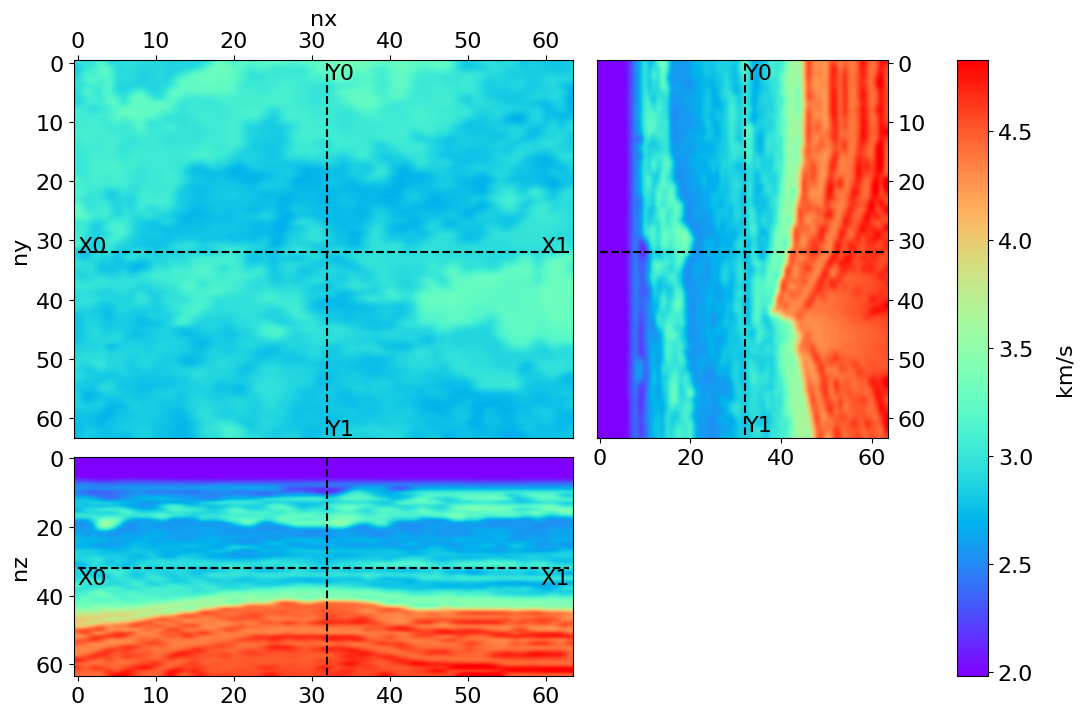

In [3]:
# Load the true model
vel_compass_3d = np.load('../data/compass_vp3d.npy')
vp_true = resize(vel_compass_3d[::14,::10,::5], (64,64,64))

m_vmin, m_vmax = np.percentile(vp_true, (1,99))

plot_slices(vp_true.T, 
    aspect='auto', interpolation='bicubic', cmap='rainbow', 
    vmin=m_vmin,vmax=m_vmax, 
    size=8,
)

# Compass 2D

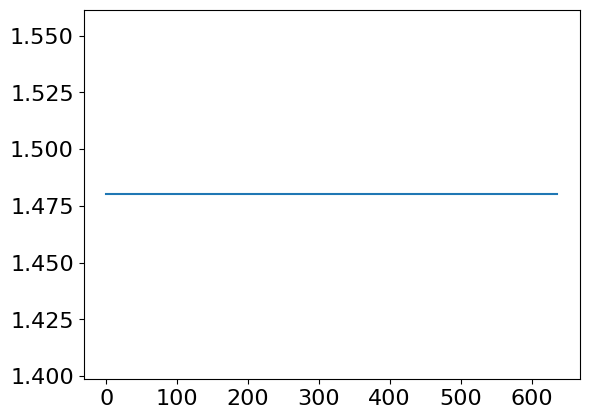

In [22]:
plt.plot(vel_compass_3d[0,:,0])

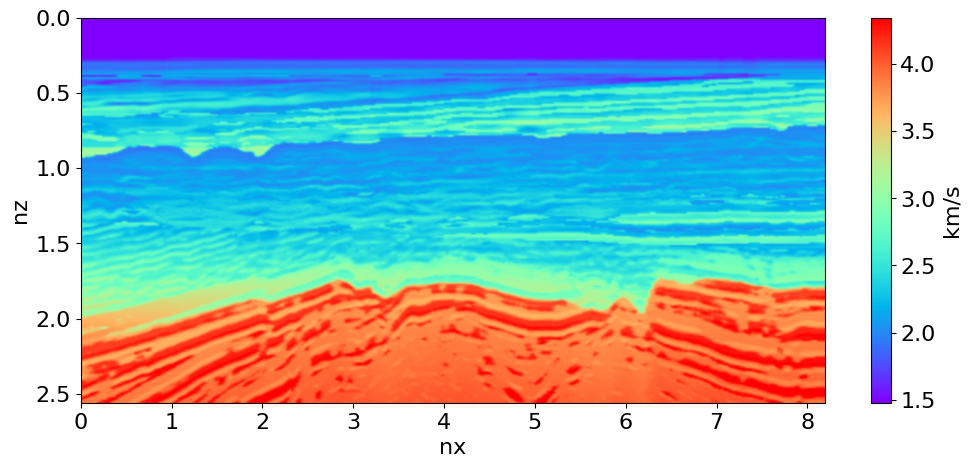

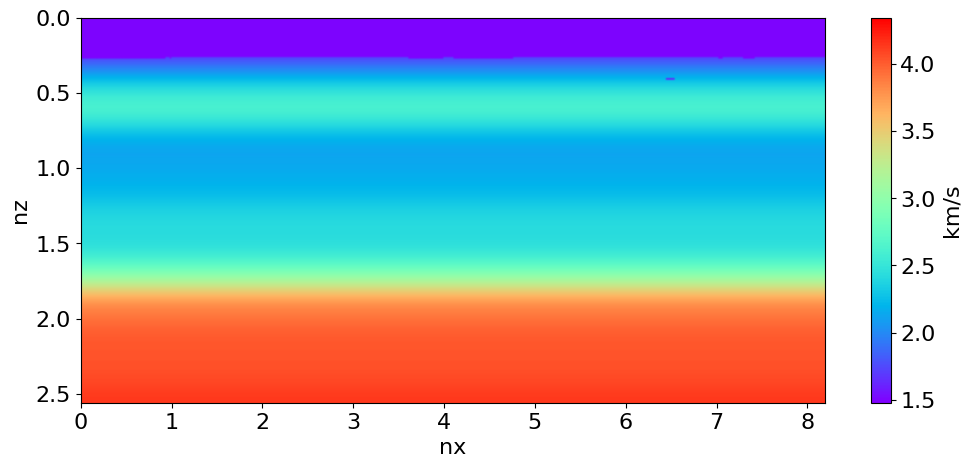

In [ ]:
# Load the true model
vel_compass_3d = np.load('../data/compass_vp3d.npy')
vp_true = resize(vel_compass_3d[:,490,:], (512,256))

mask = np.ones_like(vp_true)
mask[vp_true<1.51] = 0

vp_init = gaussian_filter(vp_true, (10,10))
vp_init[:,:] = vp_init[-1,:]

# Replace water velocity
vp_init[mask==0] = 1.5 

m_vmin, m_vmax = np.percentile(vp_true, (1,99))

plot_modulus(
    vp_true.T, 
    interpolation='bicubic', cmap='rainbow', aspect='auto',
    vmin=m_vmin,vmax=m_vmax,
    extent=[0,512*16/1e3,256*10/1e3,0]
)

plot_modulus(
    vp_init.T, 
    interpolation='bicubic', cmap='rainbow', aspect='auto',
    vmin=m_vmin,vmax=m_vmax,
    extent=[0,512*16/1e3,256*10/1e3,0]
)

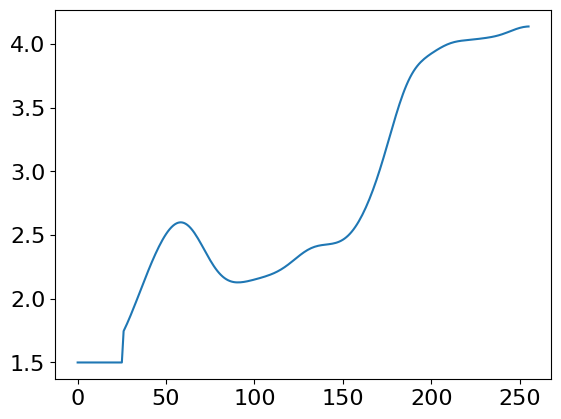

In [17]:
plt.plot(vp_init[-1])

In [20]:
vp_init[-1,26]

1.7462225